## 확률적 경사하강법 

### 최적화 문제 

`-` $loss=(\frac{1}{2}\beta-1)^2$를 최소로하는 $\beta$를 컴퓨터를 이용하여 구하는 문제를 고려하자. (우리는 답을 알고있기는 하다. $\beta=2$) 

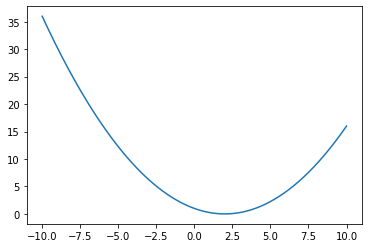

In [1]:
import numpy as np 
beta=np.linspace(-10,10,1000)
loss=(beta*0.5-1)**2
import matplotlib.pyplot as plt 
plt.plot(beta,loss)

#### 방법1: grid search

***[알고리즘1]***

(1) $[-10,-9.99,\dots,9.99,10]$와 같은 수열을 만든다. 

(2) $(-10/2-1)^2, (-9.99/2-1)^2, \dots, (9.99/2-1)^2, (10/2-1)^2$ 를 계산한다. 

(3) (2)의 결과를 가장 작게 만드는 값을 선택한다. 

`-` 비판1: $[-10,10]$의 구간 이외에 해가 존재한다면? 이 예제의 경우에는 운좋게 $[-10,10]$에서 해가 존재했으나, 임의의 고정된 $x$,$y$에 대하여

$$loss(\beta)=(x\beta-y)^2$$
  
와 같은 손실함수를 고려한다면 구간 $[-10,10]$에 최소값이 존재하리라는 보장이 없다. 

`-` 비판2: 효율적이지 않다. 그리드서치의 알고리즘을 요약하면 -10부터 10까지 작은 간격으로 조금씩 이동하며 loss를 조사하는 것이다. 그런데, $\beta=2$인 순간의 $loss=(\frac{1}{2}\beta-1)^2=0$ 이 되어서 이것보다 loss를 작게 할 수 없다는 것을 알 수 있다 (제곱은 항상 양수이므로). 따라서 $\beta=2$ 이후로는 탐색할 필요가 없다. 

#### 방법2: gradient descent 

***[알고리즘2]***

(1) 임의의 초기값을 선정하고 loss를 계산한다. 
- $\beta=-5 \to loss(-5)=(-5/2-1)^2=12.25$

(2) 임의의 초기값에서 좌우로 약간씩 이동하여 본다. 그리고 loss를 계산한다. 
 - 왼쪽으로 이동: $\beta=-5.01,~~ loss(-5.01)=12.285025$
 - 오른쪽으로 이동: $\beta=-4.99,~~ loss(-4.99)=12.215025$

(3) (2)의 결과를 분석하여 어느쪽으로 이동하는것이 유리할지 따져보고 `유리한 방향`으로 이동한다. 
 - $\beta=-4.99$ 로 이동

(4) (2)-(3)의 과정을 반복한다. 왼쪽/오른쪽 모두 가봐도 유리한 지점이 없다면 알고리즘을 멈춘다. 

`-` 알고리즘이 멈추는 지점은 $\beta=2$ 이다. 왜냐하면 이 경우 왼쪽으로 가도, 오른쪽으로 가도 현재 손실함수의 값보다 크기 때문. 

`-` 이 알고리즘은 $loss=(x\beta-y)^2$의 꼴에서 $[-10,10]$ 이외의 지점에 해가 존재하여도 적절하게 해를 찾을 것이다. 

`-` 또한 비효율적으로 $\beta=2$ 이후에 탐색을 반복하지 않는다 

`-` 알고리즘에서 (2)의 과정은 손실함수에 미분을 하는 과정으로 볼 수 있고 (3)의 과정은 미분계수를 해석하여 손실함수를 줄이는 쪽을 $\beta$를 조금씩 업데이트 하는 과정으로 볼 수 있다. 이처럼 손실함수의 기울기(=경사)를 계산하여 점차적으로 $\beta$를 업데이트 하는 방식을 경사하강법이라고 부른다. 

`-` 예제의 알고리즘에서는 설명의 편의성을 위해서 0.01씩 동일하게 움직인다고 가정했지만 기울기가 급할수록 더 빠르게 이동하는 것이 효율적이다. 아래의 그림에서 

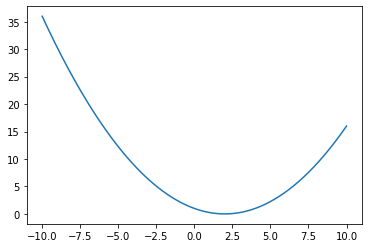

In [5]:
plt.plot(beta,loss)

$\beta=-10$ 인 경우 접선의 기울기는 $-12$ 이고, $\beta=-4$ 일때는 접선의 기울기는 $-6$ 이 된다. 따라서 $\beta=-10$ 일 경우에 0.01 움직였다면 $\beta=-4$ 일 경우에는 $0.005$ 만큼 움직이는 것이 맞다는 의미이다. 이처럼 움직이는 폭은 접선의 기울기와 비례하여 움직여야 타당한데 이를 수식으로 나타내면 아래와 같다. 

$$\beta_{next} \leftarrow \beta_{old} -\alpha \frac{\partial}{\partial \beta}loss(\beta)$$

여기에서 $\alpha$는 양수라고 하자. 이때 $\alpha$는 더 좋은 $\beta$를 찾기 위해서 얼마나 조금씩 이동할지 결정하는 파라메터이다. 앞서 예로 들었던 $\beta= -10$ 에서 0.01 만큼 움직이려면 $\alpha=\frac{0.01}{12}$ 이어야 한다. 

`-` 이번에는 아래와 같은 함수를 고려하여 보자. 

$$loss(\beta_1,\beta_2)=(x_1\beta_1 +x_2\beta_2 -y)^2 = (\beta_1+\beta_2-2)^2$$

우리는 이미 최적값을 알고 있다. ($\beta_1,\beta_2)=(1,1)$에서 최저값을 가진다. 이 최저값을 경사하강법으로 찾는다고 하면 

(1) $(\beta_1,\beta_2)$를 적당한 값으로 초기화 한다. 

(2) 초기값 $\beta_1,\beta_2$에서 각각 0.01씩 더하거나 빼보면서 loss를 계산하고 유리한 방향을 선택하여 움직인다. 

`-` 여기에서 (2)의 과정을 좀 더 자세히 살펴보면 아래와 같다. 
 - (i) $\beta_2$를 고정하고 $\beta_1$에서 0.01씩 더하거나 빼보면서 더하는 것이 유리한지 뺴는것이 유리한지 판단
 - (ii) $\beta_1$를 고정하고 $\beta_2$에서 0.01씩 더하거나 빼보면서 더하는 것이 유리한지 뺴는것이 유리한지 판단

`–` 방향이 결정되었다면 각각의 방향으로 얼만큼 이동할지를 결정해야 하는데, 이는 편미분의 계수로 판단한다. 예를들어 $\beta_1$을 0.01 만큼 변화시키면 $\beta_2$를 0.01만큼 변화시키는 것보다 손실함수의 감소폭이 2배 더 크다고 하자. 이때는 $\beta_1$을 더 많이 수정하는 것이 유리하다. 예컨데 $\beta_1$을 0.02만큼 변화시키고 $\beta_2$는 0.01만큼 변화시킨다. 즉 

$$ {\boldsymbol \beta}_{new} \leftarrow {\boldsymbol \beta}_{old} +\begin{bmatrix} 0.02 \\0.01 \end{bmatrix}$$  

와 같은 말이다. 여기에서 $\begin{bmatrix} 0.02 \\0.01 \end{bmatrix}$은 학습률과 그레디언트의 곱으로 해석할 수 있다. 즉 아래와 같이 볼 수 있다. 

$$\begin{bmatrix} 0.02 \\0.01 \end{bmatrix}= -\alpha \begin{bmatrix} \frac{\partial}{\partial \beta_1} \\ \frac{\partial}{\partial \beta_2} \end{bmatrix}loss(\beta_1,\beta_2) $$

#### 경사하강법에 대한 비판 

`-` 손실함수의 모양이 아래와 같다고 하자. 

$$loss=\beta(\beta-1)(\beta-3)(\beta-3.01)$$



그림을 그려보면 아래와 같다. 

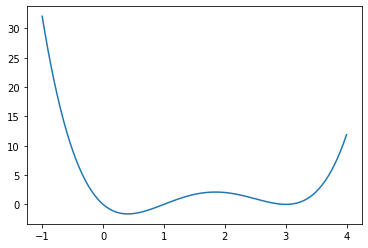

In [8]:
beta=np.linspace(-1,4,100)
loss=beta*(beta-1)*(beta-3)*(beta-3.01)
plt.plot(beta,loss)

이러한 모양의 함수는 반드시 최소점을 구할 수 있다고 장담하기 어렵다. (극소점을 찾을 수는 있음) 

`-` 최소점을 찾지 못하고 극소점에 갇히는 경우를 전역최소점(global minimum)을 찾지 못하고 국소최소점(local minimum)을 찾은 경우라 표현한다. 

`-` 경사하강법으로 찾은 해가 전역최소점임을 주장하기 위해서는 함수의 모양이 

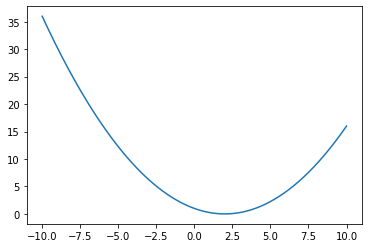

In [9]:
beta=np.linspace(-10,10,1000)
loss=(beta*0.5-1)**2
import matplotlib.pyplot as plt 
plt.plot(beta,loss)

와 같은 모양이어야 하는데 (아래로 볼록한 이차함수) 이러한 함수를 convex 함수라고 한다. 

`-` 즉 손실함수가 convex일 경우에 경사하강법으로 찾은 해가 의미가 있다. 

`-` 참고: 모든 선형모형은 손실함수가 convex이다. 

#### 경사하강법에 대한 비판2 

`-` 이번의 비판은 다소 실용적인 측면에서의 비판이다. 

`-` 예제로 들어왔던 

$$loss(\beta)=(x\beta-y)^2$$

이런 모양의 손실함수와 다르게 우리가 실제로 고민할 손힐함수의 현태는 아래와 같다. 

$$loss(\beta)=\sum_{i=1}^{n}(x_i\beta-y_i)^2$$

가령 $n$개의 관측치가 있고 각 관측치가 $(2,3),\dots,(6,8.7)$ 이라면 

$$loss(\beta)=(2\beta-3)^2+\dots+(6\beta-8.7)^2$$

이다. 

`-` 학습을 하는 도중에 데이터가 추가되어 $n+1$이 되었다고 하자. 어떻게 해야할까? 
 - 전략1: 학습하던 것을 중단하고 처음부터 $n+1$개의 자료를 고려하여 다시 학습한다. 
 - 전략2: 이미 학습하여 업데이트된 파라메터는 냅두고 이제부터라도 $n+1$개의 자료를 고려하여 학습하기 시작한다. 

#### 방법3: stochastic gradient descent 

`-` 일반적으로 경사하강법은 모든 샘플 ($n$개의 샘플)을 이용하여 $\beta$ 혹은 ${\bf w}$를 업데이트 한다. 이렇게 모든 샘플을 이용하는 방법을 `배치학습`이라고 한다. 

`-` 이와 대조적으로 극단적으로 샘플 하나만을 이용하여 파라메터를 업데이트 하는 방법을 확률적 경사하강법이라고 한다. 
 - 보통 머리글자만 따서 SGD라고 표현한다. 

`-` 대략적인 알고리즘은 아래와 같다. 

(1) $n$개 샘플의 순서를 섞는다. 

(2) 섞인 샘플에서 하나의 관측치만 이용하여 순서대로 loss를 계산하여 $\beta$를 업데이트 한다. (따라서 $n$번 업데이트 된다.) 

(3) (2)의과정이 끝나면 (하나의 세대, 하나의 에폭이 끝났다고 말한다) 다시 (1)로 돌아가서 샘플의 순서를 섞고 반복한다. 

#### 방법4: mini-batch gradient descent 

`-` 방법2와 방법3은 너무 양 극단처럼 느껴진다. 

`-` 절충안

***[알고리즘]***

(1) $n$개의 자료에서 무작위로 $m$개의 샘플을 추출한다. 

(2) $m$의 샘플을 전체자료라고 생각하고 경사하강법을 수행한다. 

(3) 다시 (1)로 돌아가서 $m$개의 샘플을 무작위로 추출하고, 수렴할때까지 반복하면 된다. 

`-` 배치와 스토캐스틱 방법은 에폭마다 훈련집합의 모든 샘플이 빠지지 않고 충실히 참여하여 기울기를 계산한다. 

`-` 미니배치방식은 운에 따라서 참여하지 않는 샘플이 있을 수 있다. 

`-` 그렇지만 미니배치가 전체 샘플의 대표성을 가지므로 미니배치로 훈련해도 해를 잘 찾는다. 

***[다른버전의 알고리즘]***: 훈련집합이 모두 사용되게끔 미니배치를 구성하는 알고리즘도 존재함. 

(1) 훈련집합을 미니배치단위로 나눈다. 

(2) 미니배치를 순서대로 처리한다. 

`-` 모든 샘플이 참여한다. 그런데 연관성이 높은자료들이 연속으로 저장될 수 있으므로 미니배치를 나누기전에 순서를 충분히 섞어준다. 

#### 방법 2,3,4 에 대한 고찰 

`-` 속도: 미니배치 기법이 가장 빠르다. 

`-` 수렴모양: 확률적 경사하강법은 갈팡질팡하면서 수렴하는 모양새. 배치기법은 안정적으로 수렴하는 모양새. 미니배치는 그 중간. 

`-` 전역해/국소해 
- 손실함수가 컨벡스: 경사하강법이 해를 안정적으로 잘 찾는다. 확률적경사하강법은 최소점 근처에서 갈팡질팡할 수 있다. 미니배치는 그 양 극단의 중간이다. 
- 손실함수가 컨벡스가 아님: 경사하강법은 국소해로 빠진다(국소해를 잘 찾는다고 해석해야 할것 같음). 확률적경사하강법은 국소해에서 갈팡질팡하다가 국소해를 운좋게 탈출할 수 있다. 미니배치는 그 중간. 

`-` 온라인학습 (중간에 샘플이 추가되는 경우) 

- 경사하강법: 처음부터 다시 학습해야함. 

- 미니배치/확률적경사하강법: 이어서 학습해도 크게 상관없다. (온라인 학습에 더 유리하다기 보다, 온라인 학습이어도 상관없다는 뉘앙스) 

### 용어 정리 및 결론 

#### 결론 

`-` 대세는 미니배치이다. 

#### 용어정리 

`-` 방법2를 지칭하는 용어는 명확하다. 

`-` 방법4를 지칭하는 방법이 애매한데 어떤사람은 이 방식을 미니배치 방식이라고 부르기도 하고, 확률적 경사하강법이라 부르는 사람도 있다. 

`-` 또한 방법4의 변형된 형태는 모든 샘플이 참여하게끔 하는 버전도 있는데 이때 batch-size=1로 생각하면 방법3과 동일하게 된다. 